# Scenario A1 Mixed: Single Supplier — No REC (Mixed Prosumers)

**Description:** Baseline scenario with mixed prosumer characterisation. Single
supplier mandate, one balancing group. Prosumers are modelled as **full prosumers**
— both local load consumption AND RES generation are billed separately, reflecting
the realistic case where a prosumer is also a consuming household or commercial site.

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 1 — SUP_A |
| Balancing Groups | 1 — BG_A (all 9 participants) |
| RECs | None |
| Prosumer type | **Mixed** (RES + local load both billed) |
| Battery | None |

**Research role:** Mixed-profile baseline. Quantifies how the presence of prosumer
local load changes imbalance exposure and supplier P&L relative to A1 (net generator
baseline), before any REC or BG restructuring is introduced.

**Comparison pairs:**
- A1-mixed vs A1 → effect of prosumer load inclusion (net gen vs mixed)
- A1-mixed vs A2-mixed → value of REC for mixed prosumers
- A1-mixed vs B1-mixed → multi-supplier effect under mixed-profile assumption

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [8]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [9]:
CONFIG_FILE = "A1_single_supplier_no_rec_mixed.json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="A1_mixed")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts
2. **Intra-Day Market** - Adjust positions with updated ID forecasts  
3. **REC Settlement** - (Skipped for A1 - no REC configured)
4. **Balancing Market** - Settle imbalances at dual pricing
5. **Supplier Billing** - Calculate final costs per participant

In [10]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: A1_mixed
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: A1_mixed
  System  : Single Supplier Mandate without REC - Scenario A1
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 1
  Prosumers    : 3
  Consumers    : 6
  RECs         : 0  →  has_rec = False
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 9)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 9)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (35136, 8)
✓ ID market : (35136, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: SKIPPED (no RECs in config)
✓ Balancing market: (35136, 27)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (12, 26)
✓ Profit/loss calculated

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for the supplier.

In [11]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – A1_MIXED

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €      174.75
      Balancing Rewards   : €       72.08
      Retail Sales        : €   37,953.39
      ────────────────────────────────────────────
      Total Revenue       : €   38,200.22

    COSTS:
      Market Purchases    : €    5,255.00
      Balancing Penalties  : €       71.73
      Retail Purchases     : €    3,357.64
      ────────────────────────────────────────────
      Total Costs          : €    8,684.37

    PROFIT/LOSS:
      Annual Total         : €   29,515.86
      Monthly Average      : €    2,459.65

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :        -0.00 MWh
      BG Actual Position   :       148.07 MWh
      BG Forecast Position :       148.08 MWh



## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

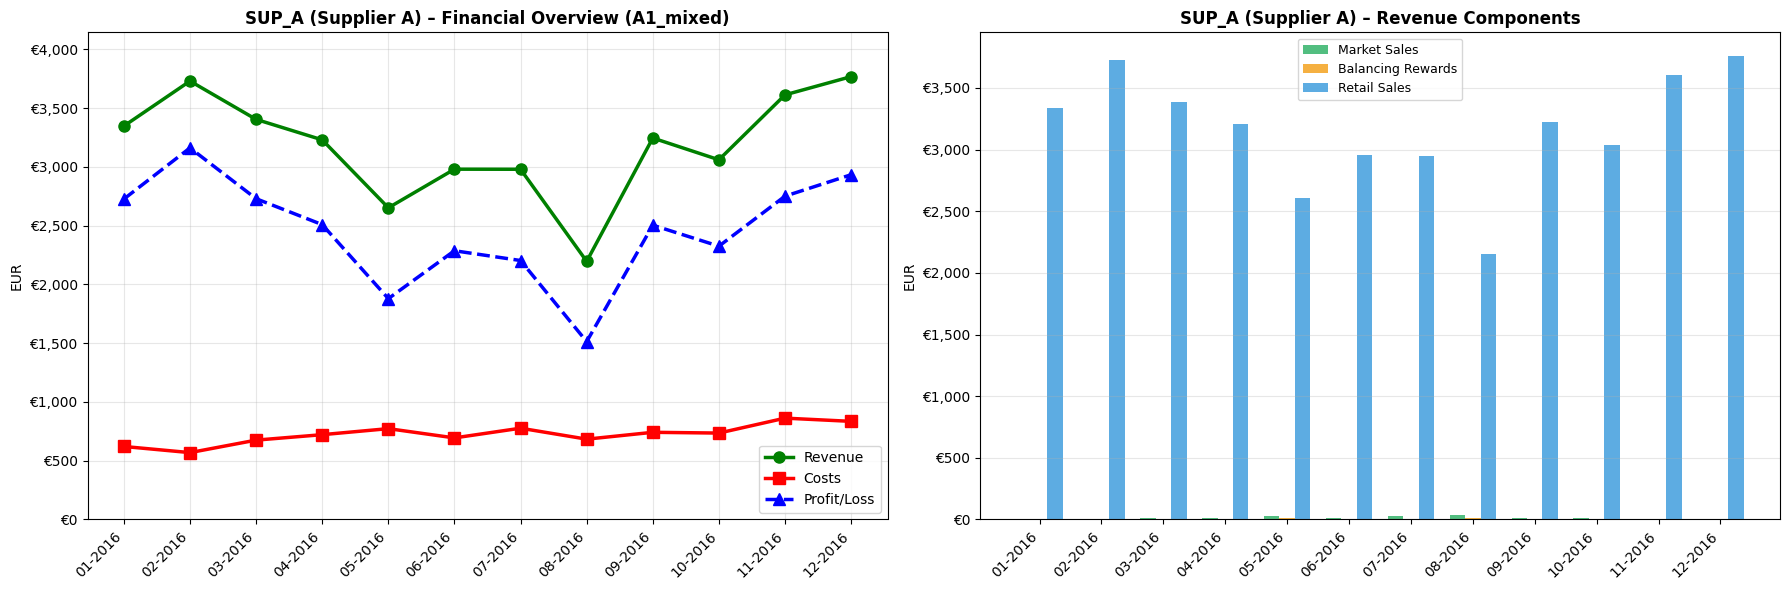

In [12]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

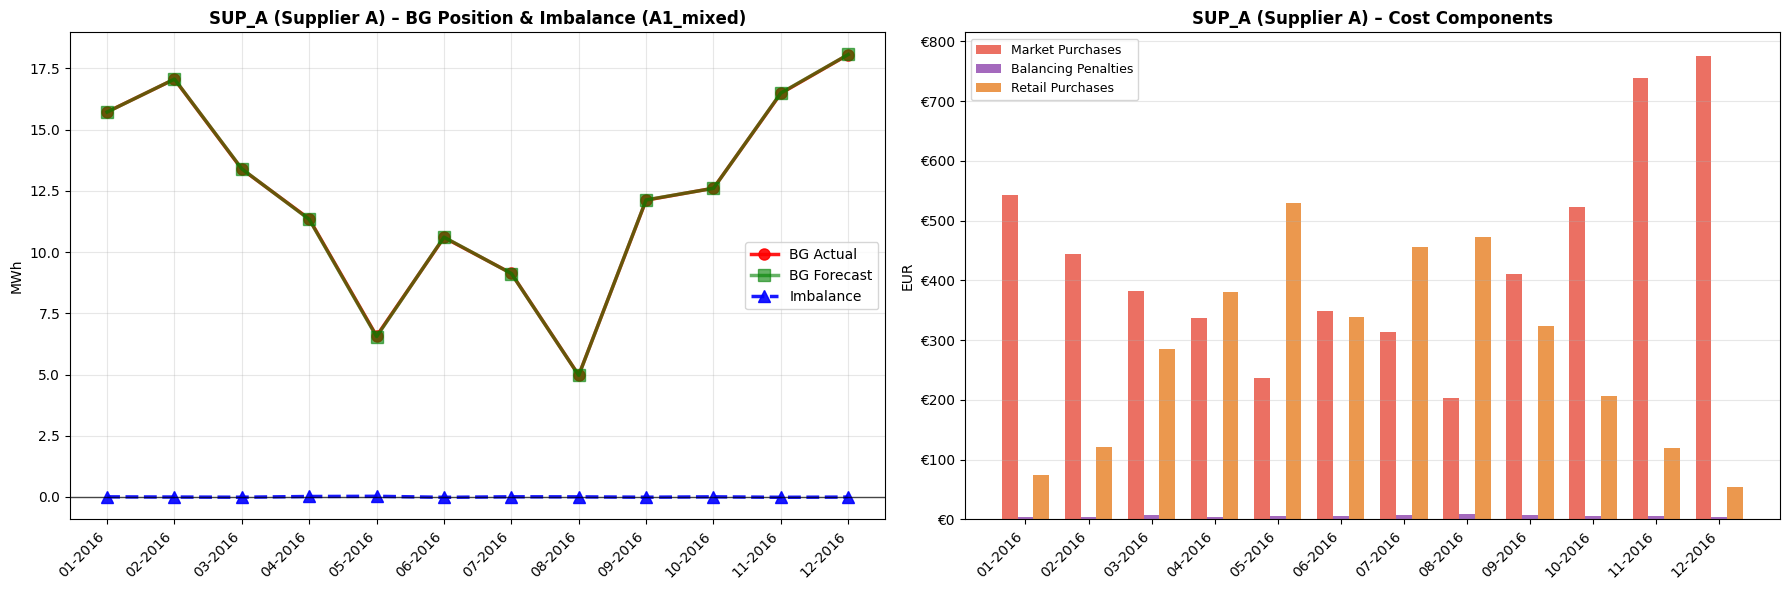

In [13]:
pipe.plot_imbalances()

## 7. Monthly Analysis Data
Display the detailed monthly analysis DataFrame with all financial metrics broken down by month.

In [14]:
pipe.es_monthly_analysis_df

,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,purchase_costs_eur,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,17.532878,0.074406,602.281473,1.797368,-1.715450,0.024128,29.579375,...,73.821276,2.439240,4.131813,3340.375280,3346.946333,543.221850,3.759606,73.821276,620.802733,2726.143600
1,02-2016,SUP_A,BG_A,19.107729,0.065242,494.289117,1.000277,-1.958210,0.018489,22.463459,...,120.725650,1.288584,4.491525,3723.843232,3729.623341,443.587695,4.392938,120.725650,568.706284,3160.917057
2,03-2016,SUP_A,BG_A,16.039708,0.803732,430.267683,11.430321,-1.769806,0.066489,24.094009,...,284.738878,12.666183,5.287190,3385.628868,3403.582240,382.896448,7.306179,284.738878,674.941505,2728.640735
3,04-2016,SUP_A,BG_A,13.856790,0.740528,382.911009,13.180574,-1.689523,0.091747,25.257687,...,379.974048,14.870016,5.622943,3208.834028,3229.326987,336.375362,4.916169,379.974048,721.265579,2508.061408
4,05-2016,SUP_A,BG_A,10.088920,2.039926,272.346920,26.667326,-1.279075,0.222535,22.993579,...,528.880123,31.054428,8.983114,2611.262593,2651.300135,237.357643,6.359462,528.880123,772.597228,1878.702908
5,06-2016,SUP_A,BG_A,12.938537,0.718319,394.866299,13.262446,-1.509338,0.099243,27.651608,...,339.558274,15.582818,6.141136,2958.174974,2979.898929,348.456915,5.787373,339.558274,693.802563,2286.096366
6,07-2016,SUP_A,BG_A,12.010879,1.250522,358.242903,22.689101,-1.492098,0.143167,27.138380,...,455.366228,25.913868,7.214823,2946.082216,2979.210907,313.747924,7.233370,455.366228,776.347522,2202.863385
7,08-2016,SUP_A,BG_A,7.787415,1.567736,233.787697,32.690097,-1.046827,0.206594,27.268374,...,471.846808,37.888653,7.923552,2149.930009,2195.742214,202.513268,8.709591,471.846808,683.069667,1512.672547
8,09-2016,SUP_A,BG_A,14.312761,0.463877,462.929502,10.440456,-1.632672,0.084286,30.137590,...,323.213901,12.703429,7.519984,3224.748089,3244.971501,410.206575,7.952185,323.213901,741.372661,2503.598840
9,10-2016,SUP_A,BG_A,14.612840,0.380204,585.042861,12.835531,-1.552765,0.074982,36.908256,...,206.526637,15.439746,6.164883,3038.231537,3059.836166,522.318391,6.098839,206.526637,734.943867,2324.892298
